In [3]:
import os
print(os.getcwd())


C:\Users\sande


In [ ]:
df = pd.read_csv(file_path)

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# Load your dataset
df = pd.read_csv("cltv3.csv")

# Feature Engineering
df_features = pd.DataFrame()
df_features["Frequency"] = df["Total_Transactions"]
df_features["Recency"] = df["Last_Transaction_Days_Ago"]
df_features["AOV"] = df["Total_Spent"] / df["Total_Transactions"]
df_features["LTV"] = df["LTV"]

# Define features and target
X = df_features[["Frequency", "Recency", "AOV"]]
y = df_features["LTV"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Absolute Error (MAE): 8281.751643943688
Root Mean Squared Error (RMSE): 10779.536016255563


In [14]:
df["Frequency"] = df["Total_Transactions"]


In [16]:
df["Recency"] = df["Last_Transaction_Days_Ago"]


In [20]:
df["AOV"] = df["Total_Spent"] / df["Total_Transactions"]


In [22]:
df_features = pd.DataFrame()
df_features["Frequency"] = df["Total_Transactions"]
df_features["Recency"] = df["Last_Transaction_Days_Ago"]
df_features["AOV"] = df["Total_Spent"] / df["Total_Transactions"]


In [26]:
print(df_features[["Frequency", "Recency", "AOV"]])  # Print all rows


      Frequency  Recency           AOV
0           192      209  16736.384023
1           979      240  14536.734683
2           329       21   7061.372800
3            71      285  16426.876453
4           878      329  10800.092660
...         ...      ...           ...
6995        340       20    162.703503
6996        647      252   1575.707877
6997        481      348  14429.355178
6998        574       50   8005.027184
6999        825      189  15697.668867

[7000 rows x 3 columns]


In [28]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [50]:
df = pd.read_csv('"C:\Users\sande\Downloads\cltv3"')  # Forward slashes


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 3-4: truncated \UXXXXXXXX escape (3534048484.py, line 1)

In [52]:
import pandas as pd

# Ensure the correct file path and format
file_path = r'C:\Users\sande\Downloads\cltv3.csv'

# Attempt to read the CSV file
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
except FileNotFoundError as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Error: [Errno 2] No such file or directory: 'C:\\Users\\sande\\Downloads\\cltv3.csv'


In [56]:
df = pd.read_csv(r'"C:\Users\sande\Downloads\cltv3new.csv"')


OSError: [Errno 22] Invalid argument: '"C:\\Users\\sande\\Downloads\\cltv3new.csv"'

In [58]:
df = pd.read_csv(r'C:\Users\sande\Downloads\cltv3new.csv')


In [60]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df = pd.read_csv(r'C:\Users\sande\Downloads\cltv3new.csv')  # Update path if needed

# Check the data
print(df.head())
print(df.columns)

# 1. Define features (X) and target (y)
# Replace 'target_column_name' with the actual column name you're predicting
X = df.drop(columns='target_column_name')  # features
y = df['target_column_name']               # target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


  Customer_ID  Age  Location Income_Level  Total_Transactions  \
0   cust_0000   54     Urban          Low                 192   
1   cust_0001   67  Suburban         High                 979   
2   cust_0002   44     Urban         High                 329   
3   cust_0003   30     Rural         High                  71   
4   cust_0004   58     Urban       Middle                 878   

   Avg_Transaction_Value  Max_Transaction_Value  Min_Transaction_Value  \
0           16736.384023           60216.834510            6525.814861   
1           14536.734683           48350.100272            2186.742245   
2            7061.372800           32521.157187            2743.406808   
3           16426.876453           17827.896720            4360.784994   
4           10800.092660           17497.634534            4532.872520   

    Total_Spent  Active_Days  Last_Transaction_Days_Ago  \
0  3.213386e+06          140                        209   
1  1.423146e+07          229                  

KeyError: "['target_column_name'] not found in axis"

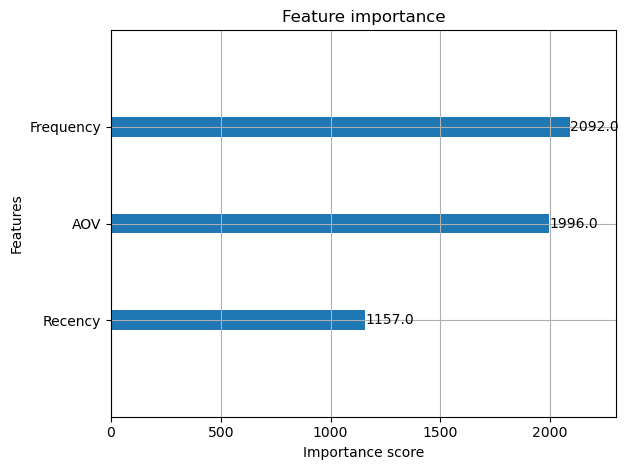

In [62]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.tight_layout()
plt.show()


In [64]:
df['predicted_ltv'] = model.predict(X)


In [66]:
df['ltv_segment'] = pd.qcut(df['predicted_ltv'], q=3, labels=['Low', 'Medium', 'High'])


In [72]:
segment_summary = df.groupby('ltv_segment').agg({
    'predicted_ltv': ['mean', 'count'],
    'total_orders': 'mean',
    'avg_order_value': 'mean',
    'tenure_months': 'mean'
}).round(2)

print(segment_summary)


KeyError: "Column(s) ['avg_order_value', 'tenure_months', 'total_orders'] do not exist"

In [74]:
print(df.columns.tolist())


['Customer_ID', 'Age', 'Location', 'Income_Level', 'Total_Transactions', 'Avg_Transaction_Value', 'Max_Transaction_Value', 'Min_Transaction_Value', 'Total_Spent', 'Active_Days', 'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned', 'Referral_Count', 'Cashback_Received', 'App_Usage_Frequency', 'Preferred_Payment_Method', 'Support_Tickets_Raised', 'Issue_Resolution_Time', 'Customer_Satisfaction_Score', 'LTV', 'predicted_ltv', 'ltv_segment']


In [78]:
segment_summary = df.groupby('ltv_segment').mean(numeric_only=True).round(2)
print(segment_summary)


               Age  Total_Transactions  Avg_Transaction_Value  \
ltv_segment                                                     
0            42.34              352.97                6905.20   
1            43.21              607.28               12118.64   
2            42.52              811.61               16323.40   

             Max_Transaction_Value  Min_Transaction_Value  Total_Spent  \
ltv_segment                                                              
0                         20760.46                2057.01   1714362.91   
1                         36901.47                3623.12   6741720.34   
2                         49802.11                4957.47  13127058.49   

             Active_Days  Last_Transaction_Days_Ago  Loyalty_Points_Earned  \
ltv_segment                                                                  
0                 181.56                     184.34                2500.30   
1                 184.57                     182.64                25

In [80]:
# Make sure your DataFrame has these columns: customer_id, predicted_ltv, ltv_segment
final_df = df[['customer_id', 'predicted_ltv', 'ltv_segment']]

# Export to CSV
final_df.to_csv('final_ltv_predictions.csv', index=False)

print("✅ Final LTV predictions saved as 'final_ltv_predictions.csv'")


KeyError: "['customer_id'] not in index"

In [82]:
print(df.columns)


Index(['Customer_ID', 'Age', 'Location', 'Income_Level', 'Total_Transactions',
       'Avg_Transaction_Value', 'Max_Transaction_Value',
       'Min_Transaction_Value', 'Total_Spent', 'Active_Days',
       'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned', 'Referral_Count',
       'Cashback_Received', 'App_Usage_Frequency', 'Preferred_Payment_Method',
       'Support_Tickets_Raised', 'Issue_Resolution_Time',
       'Customer_Satisfaction_Score', 'LTV', 'predicted_ltv', 'ltv_segment'],
      dtype='object')


In [84]:
# Make sure your DataFrame has the correct columns: 'Customer_ID', 'predicted_ltv', and 'ltv_segment'
final_df = df[['Customer_ID', 'predicted_ltv', 'ltv_segment']]

# Export to CSV
final_df.to_csv('final_ltv_predictions.csv', index=False)

print("✅ Final LTV predictions saved as 'final_ltv_predictions.csv'")


✅ Final LTV predictions saved as 'final_ltv_predictions.csv'


In [86]:
# Load the saved CSV to verify
final_df_check = pd.read_csv('final_ltv_predictions.csv')

# Preview the first few rows
print(final_df_check.head())


  Customer_ID  predicted_ltv  ltv_segment
0   cust_0000      329914.44            0
1   cust_0001     1435305.40            2
2   cust_0002      237631.36            0
3   cust_0003      130368.50            0
4   cust_0004      960119.40            1
